# Shapley Methods — Results Analysis

Reusable analysis notebook. Change `DATASET` in the **Configuration** cell and re-run all cells to analyse any experiment run.

Sections:
1. Configuration & Imports
2. Pipeline Timing Summary
3. Load Shapley Values
4. Global Feature Importance Comparison (bar chart)
5. Individual SHAP Scatter Plots — PC Graph
6. Individual SHAP Scatter Plots — LiNGAM Graph

## 1. Configuration & Imports

In [1]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import json, re
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

In [2]:
# ── Change these two lines to re-run analysis on any dataset ───────────
DATASET        = "mixed_no_conf_f50_s1000_p50"
MODEL          = "lgbm"

# Number of top features (ranked by ShapleyFromScratch) shown in
# the bar chart (Analysis 4) and scatter grid (Analyses 5 & 6).
N_TOP_FEATURES = 20

# ── Paths (notebook lives in notebooks/, project root is one level up) ──
BASE_DIR           = Path("..").resolve()
EXPLAINABILITY_DIR = BASE_DIR / "data" / "explainability"
CAUSAL_DIR         = BASE_DIR / "data" / "causal"
PROCESSED_DIR      = BASE_DIR / "data" / "processed"
LOGS_DIR           = BASE_DIR / "logs"

# ── Consistent colour scheme across all plots ───────────────────────────
METHOD_COLORS = {
    "Scratch":     "#636363",
    "Asymmetric":  "#2166ac",
    "Causal":      "#4dac26",
    "ShapleyFlow": "#d01c8b",
}

print(f"Dataset : {DATASET}")
print(f"Model   : {MODEL}")
print(f"Top N   : {N_TOP_FEATURES}")

Dataset : mixed_no_conf_f50_s1000_p50
Model   : lgbm
Top N   : 20


## 2. Pipeline Timing Summary

In [3]:
def parse_pipeline_timing(logs_dir: Path, dataset: str):
    """
    Parse the latest pipeline log and return:
      - timing_df  : per-method DataFrame (Method, Start, End, Duration, Per Instance, Graph Details)
      - total_str  : human-readable total execution time
    """
    log_files = sorted(logs_dir.glob("pipeline_*.log"))
    if not log_files:
        print("No log files found in", logs_dir)
        return None, "—"

    log_file = log_files[-1]
    print(f"Log file: {log_file.name}")

    ts_re   = re.compile(r"^(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}) \| (.*)$")
    prog_re = re.compile(r"\[Progress:\s*(\d+)/(\d+)\]\s+(.+)")

    events = []
    with open(log_file) as f:
        for line in f:
            m = ts_re.match(line.strip())
            if m:
                ts = datetime.strptime(m.group(1), "%Y-%m-%d %H:%M:%S")
                events.append((ts, m.group(2).strip()))

    # ── Extract ShapleyFlow graph stats per method (edges, sources) ─────
    # Format: "ShapleyFlowWrapper: 51 features, 138 edges, 9 sources"
    flow_re     = re.compile(r"ShapleyFlowWrapper:.*?(\d+) edges,\s*(\d+) sources")
    flow_stats  = {}          # keyed by progress-method-name string
    current_key = None
    for ts, content in events:
        pm = prog_re.search(content)
        if pm:
            current_key = pm.group(3).strip()
        fm = flow_re.search(content)
        if fm and current_key and current_key not in flow_stats:
            flow_stats[current_key] = (int(fm.group(1)), int(fm.group(2)))

    # ── Total execution time ─────────────────────────────────────────────
    total_min = None
    pipeline_end = None
    for ts, content in events:
        m = re.search(r"Total execution time:\s*([\d.]+)\s*minutes", content)
        if m:
            total_min    = float(m.group(1))
            pipeline_end = ts
    if pipeline_end is None and events:
        pipeline_end = events[-1][0]

    # ── Progress events ──────────────────────────────────────────────────
    prog_evts = []
    for ts, content in events:
        m = prog_re.search(content)
        if m:
            prog_evts.append({"ts": ts, "idx": int(m.group(1)), "name": m.group(3).strip()})

    if not prog_evts:
        return None, "—"

    # ── Build per-method rows ────────────────────────────────────────────
    rows = []
    for i, pe in enumerate(prog_evts):
        end_ts     = prog_evts[i + 1]["ts"] if i + 1 < len(prog_evts) else pipeline_end
        dur_s      = max(0.0, (end_ts - pe["ts"]).total_seconds()) if end_ts else 0.0
        dur_min    = dur_s / 60
        n_inst     = 100   # instances per method in the pipeline

        raw_name   = pe["name"]
        # Strip slow-warning annotation, e.g. "(SLOW - uses 10 inner samples)"
        clean_name = re.sub(r"\s*\(SLOW[^)]*\)", "", raw_name).strip()

        # ── Graph Details column ─────────────────────────────────────────
        is_pc     = "PC"     in raw_name.upper()
        is_lingam = "LINGAM" in raw_name.upper()
        is_flow   = "FLOW"   in raw_name.upper() or "ShapleyFlow" in raw_name

        if raw_name in flow_stats:
            edges, srcs = flow_stats[raw_name]
            graph_str = f"{edges} edges, {srcs} sources"
        elif is_pc:
            # Count from adjacency matrix for non-flow methods
            graph_str = "PC graph"
        elif is_lingam:
            graph_str = "LiNGAM graph"
        else:
            graph_str = "—"

        # ── Duration display ─────────────────────────────────────────────
        if dur_s < 5:
            dur_str  = "< 5 s (skipped)"
            per_str  = "—"
        elif dur_min >= 60:
            dur_str  = f"{dur_min/60:.1f} h  ({dur_min:.0f} min)"
            per_str  = f"~{dur_s/n_inst:.0f} s"
        elif dur_min >= 1:
            dur_str  = f"{dur_min:.1f} min"
            per_str  = f"~{dur_s/n_inst:.0f} s"
        else:
            dur_str  = f"{dur_s:.0f} s"
            per_str  = f"~{dur_s/n_inst:.1f} s"

        rows.append({
            "#":             pe["idx"],
            "Method":        clean_name,
            "Start":         pe["ts"].strftime("%H:%M:%S"),
            "End":           end_ts.strftime("%H:%M:%S") if end_ts else "—",
            "Duration":      dur_str,
            "Per Instance":  per_str,
            "Graph Details": graph_str,
        })

    total_str = (
        f"{total_min:.1f} min  ({total_min/60:.2f} h)" if total_min else "—"
    )
    return pd.DataFrame(rows), total_str


timing_df, total_time = parse_pipeline_timing(LOGS_DIR, DATASET)

# ── Display as Plotly table ───────────────────────────────────────────────
if timing_df is not None:
    header_vals = list(timing_df.columns)
    cell_vals   = [timing_df[c].tolist() for c in timing_df.columns]

    # Zebra-stripe rows
    n = len(timing_df)
    row_colors = [["#f0f4f8" if i % 2 == 0 else "white" for i in range(n)]] * len(header_vals)

    fig_timing = go.Figure(go.Table(
        header=dict(
            values=[f"<b>{v}</b>" for v in header_vals],
            fill_color="#2c3e50", font=dict(color="white", size=12),
            align="left", height=30,
        ),
        cells=dict(
            values=cell_vals,
            fill_color=row_colors,
            align="left", height=26,
            font=dict(size=11),
        ),
    ))
    fig_timing.update_layout(
        title=dict(
            text=f"Pipeline Timing Summary — {DATASET}<br>"
                 f"<sup>Total execution time: {total_time}</sup>",
            font=dict(size=14),
        ),
        margin=dict(l=10, r=10, t=60, b=10),
        height=60 + 30 + n * 28,
    )
    fig_timing.show()
else:
    print("Could not parse timing log.")

Log file: pipeline_20260506_172253.log


## 3. Load Shapley Values

In [4]:
exp_dir = EXPLAINABILITY_DIR / DATASET / MODEL

# ── Method registry ───────────────────────────────────────────────────────
# key  : display name used across all plots
# value: relative path inside exp_dir
METHOD_PATHS = {
    "Scratch":                exp_dir / "scratch"  / "shapley_values.npy",
    "Asymmetric (PC)":        exp_dir / "pc"       / "asymmetric" / "shapley_values.npy",
    "Causal (PC)":            exp_dir / "pc"       / "causal"     / "shapley_values.npy",
    "Flow (PC)":              exp_dir / "pc"       / "flow"       / "shapley_values.npy",
    "Asymmetric (LiNGAM)":   exp_dir / "lingam"   / "asymmetric" / "shapley_values.npy",
    "Causal (LiNGAM)":       exp_dir / "lingam"   / "causal"     / "shapley_values.npy",
    "Flow (LiNGAM)":         exp_dir / "lingam"   / "flow"       / "shapley_values.npy",
}

shap_data = {}
for name, path in METHOD_PATHS.items():
    if path.exists():
        sv = np.load(path)
        shap_data[name] = sv
        nan_pct = 100 * np.isnan(sv).mean()
        zero_pct = 100 * (sv == 0).mean()
        print(f"  {name:28s}  shape={sv.shape}  "
              f"mean|SHAP|={np.abs(sv).mean():.4f}  "
              f"NaN={nan_pct:.1f}%  zeros={zero_pct:.1f}%")
    else:
        print(f"  {name:28s}  NOT FOUND: {path}")

# ── Feature names (X only, no Y) ─────────────────────────────────────────
with open(CAUSAL_DIR / f"{DATASET}_pc_results.json") as f:
    pc_results = json.load(f)
with open(CAUSAL_DIR / f"{DATASET}_lingam_results.json") as f:
    lingam_results = json.load(f)

feature_names = [n for n in pc_results["feature_names"] if n != "Y"]
n_features    = len(feature_names)

# ── Test instances used for SHAP (first n_shap rows of test set) ──────────
n_shap   = shap_data["Scratch"].shape[0]
test_df  = pd.read_parquet(PROCESSED_DIR / f"{DATASET}_test.parquet")
x_test   = test_df[feature_names].iloc[:n_shap].values   # shape: (n_shap, n_features)

# ── Graph statistics ──────────────────────────────────────────────────────
def _flow_graph_stats(adj_list, n_x):
    """Return (total_edges, n_source_nodes) for a (n_x+1)×(n_x+1) adjacency."""
    adj   = np.array(adj_list)
    total = int(np.sum(adj != 0))
    # Backward BFS from Y (last node) to find ancestors
    n     = adj.shape[0]
    parents = {i: np.where(adj[:, i] != 0)[0].tolist() for i in range(n)}
    reachable, queue = set(), [n - 1]
    while queue:
        node = queue.pop()
        if node not in reachable:
            reachable.add(node)
            queue.extend(parents[node])
    # Source = in-degree 0 in X-only subgraph AND reachable from Y
    x_adj    = adj[:n_x, :n_x]
    in_deg   = np.sum(x_adj != 0, axis=0)
    sources  = [i for i in range(n_x) if in_deg[i] == 0 and i in reachable]
    return total, len(sources)

pc_edges,     pc_sources     = _flow_graph_stats(pc_results["adjacency_matrix"],     n_features)
lingam_edges, lingam_sources = _flow_graph_stats(lingam_results["adjacency_matrix"], n_features)

print(f"\nFeatures : {n_features}    SHAP instances : {n_shap}")
print(f"PC graph     : {pc_edges} edges, {pc_sources} sources")
print(f"LiNGAM graph : {lingam_edges} edges, {lingam_sources} sources")

  Scratch                       shape=(100, 50)  mean|SHAP|=0.0227  NaN=0.0%  zeros=12.0%
  Asymmetric (PC)               shape=(100, 50)  mean|SHAP|=0.0235  NaN=0.0%  zeros=19.7%
  Causal (PC)                   shape=(100, 50)  mean|SHAP|=0.0300  NaN=0.0%  zeros=0.0%
  Flow (PC)                     shape=(100, 50)  mean|SHAP|=0.0245  NaN=0.0%  zeros=43.9%
  Asymmetric (LiNGAM)           shape=(100, 50)  mean|SHAP|=0.0223  NaN=0.0%  zeros=22.3%
  Causal (LiNGAM)               shape=(100, 50)  mean|SHAP|=0.0307  NaN=0.0%  zeros=2.0%
  Flow (LiNGAM)                 shape=(100, 50)  mean|SHAP|=0.0216  NaN=0.0%  zeros=22.6%

Features : 50    SHAP instances : 100
PC graph     : 138 edges, 9 sources
LiNGAM graph : 287 edges, 3 sources


## 4. Global Feature Importance Comparison

Mean absolute SHAP value per feature.  
**Left panel** — ShapleyFromScratch + PC-graph methods.  
**Right panel** — ShapleyFromScratch + LiNGAM-graph methods.  
Features are sorted (left → right) by ShapleyFromScratch importance.

In [5]:
# ── Mean absolute SHAP per feature ───────────────────────────────────────
mean_abs = {name: np.abs(sv).mean(axis=0) for name, sv in shap_data.items()}

# Top-N features ranked by Scratch
scratch_rank  = np.argsort(mean_abs["Scratch"])[::-1][:N_TOP_FEATURES]
top_features  = [feature_names[i] for i in scratch_rank]

# ── Build long-format DataFrame (one row per feature × method × graph) ───
PC_METHODS     = ["Scratch", "Asymmetric (PC)",     "Causal (PC)",     "Flow (PC)"]
LINGAM_METHODS = ["Scratch", "Asymmetric (LiNGAM)", "Causal (LiNGAM)", "Flow (LiNGAM)"]

rows = []
for method in PC_METHODS:
    src_key = "Scratch" if method == "Scratch" else method
    if src_key not in mean_abs:
        continue
    label = method.replace(" (PC)", "")
    for fi in scratch_rank:
        rows.append(dict(
            Feature=feature_names[fi],
            Method=label,
            Graph=f"PC  ({pc_edges} edges, {pc_sources} sources)",
            Importance=float(mean_abs[src_key][fi]),
        ))

for method in LINGAM_METHODS:
    src_key = "Scratch" if method == "Scratch" else method
    if src_key not in mean_abs:
        continue
    label = method.replace(" (LiNGAM)", "")
    for fi in scratch_rank:
        rows.append(dict(
            Feature=feature_names[fi],
            Method=label,
            Graph=f"LiNGAM  ({lingam_edges} edges, {lingam_sources} sources)",
            Importance=float(mean_abs[src_key][fi]),
        ))

df_imp = pd.DataFrame(rows)
df_imp["Feature"] = pd.Categorical(df_imp["Feature"], categories=top_features, ordered=True)

# ── Plot ──────────────────────────────────────────────────────────────────
fig_imp = px.bar(
    df_imp,
    x="Feature", y="Importance", color="Method",
    barmode="group",
    facet_col="Graph",
    facet_col_spacing=0.06,
    category_orders={
        "Feature": top_features,
        "Method":  ["Scratch", "Asymmetric", "Causal", "Flow"],
    },
    color_discrete_map={
        "Scratch":     METHOD_COLORS["Scratch"],
        "Asymmetric":  METHOD_COLORS["Asymmetric"],
        "Causal":      METHOD_COLORS["Causal"],
        "Flow":        METHOD_COLORS["ShapleyFlow"],
    },
    labels={"Importance": "Mean |SHAP|", "Feature": ""},
    title=(
        f"Global Feature Importance — Top {N_TOP_FEATURES} Features "
        f"(sorted by Scratch) — {DATASET}"
    ),
    height=480,
    width=1300,
)

# Shared y-axis so both panels are directly comparable
fig_imp.update_yaxes(matches="y")
fig_imp.update_layout(
    legend_title_text="Method",
    margin=dict(t=80, b=60),
)
fig_imp.show()

## 5. Individual SHAP Scatter Plots — PC Graph

Grid: **rows** = top-N features  ·  **columns** = [Scratch, Asymmetric, Causal, ShapleyFlow]  
Each cell: SHAP value (y) vs. feature value x (x) for all test instances.  
Y-axis scale is **shared within each row** so magnitudes are comparable across methods.

In [6]:
def make_shap_scatter_figure(
    methods:        list,   # ordered list of display names to use as columns
    col_labels:     list,   # short column header for each method
    feature_idx:    list,   # feature indices (rows)
    feature_labels: list,   # feature name for each row
    x_test:         np.ndarray,
    shap_data:      dict,
    title:          str,
    colors:         dict,
) -> go.Figure:
    """
    Build an (n_features × n_methods) scatter grid.
    Each cell: feature_value (x) vs SHAP_value (y).
    Y-axis is shared within each row.
    """
    n_rows = len(feature_idx)
    n_cols = len(methods)

    # ── Adaptive spacing ──────────────────────────────────────────────────
    # vertical_spacing is a fraction of total figure height.
    # With n_rows subplots the gaps consume  v * (n_rows - 1)  of that height.
    # Keep that budget ≤ 25 % of total so the actual subplots have room.
    # Formula: v = 0.25 / (n_rows - 1)  clamped to [0.005, 0.06]
    vertical_spacing   = max(0.005, min(0.06, 0.25 / max(n_rows - 1, 1)))
    horizontal_spacing = 0.06

    # Cell height scales so the total figure stays around 3 000 px.
    cell_h = max(120, 3000 // n_rows)

    # Column headers only in the top row; blank elsewhere
    subplot_titles = []
    for ri in range(n_rows):
        for ci in range(n_cols):
            subplot_titles.append(col_labels[ci] if ri == 0 else "")

    fig = make_subplots(
        rows=n_rows, cols=n_cols,
        subplot_titles=subplot_titles,
        shared_xaxes=False,
        shared_yaxes="rows",      # share y-scale within each feature row
        vertical_spacing=vertical_spacing,
        horizontal_spacing=horizontal_spacing,
    )

    # Style the column-header annotations produced by make_subplots
    for ann in fig.layout.annotations:
        if ann.text:
            ann.update(font=dict(size=11, color="#2c3e50"))

    for ri, (fi, feat) in enumerate(zip(feature_idx, feature_labels)):
        x_vals = x_test[:, fi]

        for ci, method in enumerate(methods):
            if method not in shap_data:
                continue
            shap_vals = shap_data[method][:, fi]

            fig.add_trace(
                go.Scatter(
                    x=x_vals,
                    y=shap_vals,
                    mode="markers",
                    marker=dict(
                        size=4,
                        color=x_vals,
                        colorscale="Viridis",
                        showscale=False,
                        opacity=0.7,
                        line=dict(width=0),
                    ),
                    name=method,
                    showlegend=False,
                    hovertemplate=(
                        f"<b>{feat}</b> — {method}<br>"
                        "x = %{x:.3f}<br>SHAP = %{y:.4f}<extra></extra>"
                    ),
                ),
                row=ri + 1, col=ci + 1,
            )

            # Zero-reference line
            x_range = [float(x_vals.min()), float(x_vals.max())]
            fig.add_trace(
                go.Scatter(
                    x=x_range, y=[0, 0],
                    mode="lines",
                    line=dict(color="gray", width=0.8, dash="dot"),
                    showlegend=False,
                    hoverinfo="skip",
                ),
                row=ri + 1, col=ci + 1,
            )

        # Feature name as y-axis label on the first column only
        fig.update_yaxes(
            title_text=feat,
            title_font=dict(size=9),
            title_standoff=4,
            row=ri + 1, col=1,
        )
        # Remove x-axis tick labels except on the last row to reduce clutter
        for ci in range(1, n_cols + 1):
            fig.update_xaxes(
                showticklabels=(ri == n_rows - 1),
                tickfont=dict(size=8),
                row=ri + 1, col=ci,
            )

    fig.update_layout(
        title=dict(text=title, font=dict(size=14)),
        height=cell_h * n_rows + 80,
        width=240 * n_cols + 120,
        margin=dict(l=90, r=20, t=80, b=40),
    )
    return fig


# ── Column metadata ───────────────────────────────────────────────────────
PC_SCATTER_METHODS = [
    "Scratch",
    "Asymmetric (PC)",
    "Causal (PC)",
    "Flow (PC)",
]
COL_LABELS = ["ShapleyFromScratch", "AsymmetricShapley", "CausalShapley", "ShapleyFlow"]

fig_scatter_pc = make_shap_scatter_figure(
    methods        = PC_SCATTER_METHODS,
    col_labels     = COL_LABELS,
    feature_idx    = scratch_rank.tolist(),
    feature_labels = top_features,
    x_test         = x_test,
    shap_data      = shap_data,
    title          = (
        f"SHAP Scatter — PC Graph ({pc_edges} edges, {pc_sources} sources) — "
        f"Top {N_TOP_FEATURES} Features — {DATASET}"
    ),
    colors         = METHOD_COLORS,
)
fig_scatter_pc.show()

## 6. Individual SHAP Scatter Plots — LiNGAM Graph

Same grid structure as above but using LiNGAM-based causal methods.  
Scratch (no graph) is repeated here as the reference baseline.

In [7]:
LINGAM_SCATTER_METHODS = [
    "Scratch",
    "Asymmetric (LiNGAM)",
    "Causal (LiNGAM)",
    "Flow (LiNGAM)",
]

fig_scatter_lingam = make_shap_scatter_figure(
    methods        = LINGAM_SCATTER_METHODS,
    col_labels     = COL_LABELS,
    feature_idx    = scratch_rank.tolist(),
    feature_labels = top_features,
    x_test         = x_test,
    shap_data      = shap_data,
    title          = (
        f"SHAP Scatter — LiNGAM Graph ({lingam_edges} edges, {lingam_sources} sources) — "
        f"Top {N_TOP_FEATURES} Features — {DATASET}"
    ),
    colors         = METHOD_COLORS,
)
fig_scatter_lingam.show()

## 7. Instance-Level SHAP Values

Select `N_INSTANCES` random test instances and compare the per-feature SHAP values across methods for the **globally-ranked top features**.

| Axis | Meaning |
|------|---------|
| **Rows** | individual test instances |
| **Columns** | Shapley methods |
| **Bars** | SHAP value per feature (🔵 positive contribution, 🔴 negative contribution) |

Feature order is fixed to the global importance ranking (most important at top). This makes it easy to spot how attributions shift across instances and methods.

In [8]:
# ── Instance-Level Config ─────────────────────────────────────────────────
N_INSTANCES = 10
_rng = np.random.default_rng(seed=42)
instance_idx = sorted(_rng.choice(len(x_test), size=N_INSTANCES, replace=False).tolist())
print(f"Selected {N_INSTANCES} instances (seed=42): {instance_idx}")


def make_instance_shap_figure(
    methods:        list,
    col_labels:     list,
    feature_idx:    list,
    feature_labels: list,
    instance_idx:   list,
    shap_data:      dict,
    title:          str,
) -> go.Figure:
    """
    (n_instances × n_methods) grid of horizontal bar charts.
    Each cell: SHAP values for the top-N features of one instance.
    Blue = positive contribution, red = negative contribution.
    Feature labels shown only in the first column; x-axis ticks only on last row.
    """
    n_rows  = len(instance_idx)
    n_cols  = len(methods)
    n_feats = len(feature_idx)

    # Adaptive row height: 22 px per bar + cell padding
    cell_h             = max(160, 22 * n_feats + 40)
    vertical_spacing   = max(0.005, min(0.04, 0.15 / max(n_rows - 1, 1)))
    horizontal_spacing = 0.06

    # Column headers in first row only, blank for all subsequent rows
    subplot_titles = [
        col_labels[ci] if ri == 0 else ""
        for ri in range(n_rows)
        for ci in range(n_cols)
    ]

    fig = make_subplots(
        rows=n_rows, cols=n_cols,
        subplot_titles=subplot_titles,
        shared_xaxes=False,
        shared_yaxes=False,
        vertical_spacing=vertical_spacing,
        horizontal_spacing=horizontal_spacing,
    )
    for ann in fig.layout.annotations:
        if ann.text:
            ann.update(font=dict(size=11, color="#2c3e50"))

    POS_COLOR = "#2196F3"   # blue  – positive SHAP contribution
    NEG_COLOR = "#EF5350"   # red   – negative SHAP contribution

    # Reverse order so the most important feature sits at the TOP of each bar chart
    feat_labels_top = feature_labels[::-1]
    feat_idx_top    = feature_idx[::-1]

    for ri, inst in enumerate(instance_idx):
        for ci, method in enumerate(methods):
            if method not in shap_data:
                continue

            sv     = shap_data[method][inst]
            vals   = np.array([sv[fi] for fi in feat_idx_top])
            colors = [POS_COLOR if v >= 0 else NEG_COLOR for v in vals]

            fig.add_trace(
                go.Bar(
                    x=vals,
                    y=feat_labels_top,
                    orientation="h",
                    marker=dict(color=colors, line=dict(width=0)),
                    showlegend=False,
                    hovertemplate=(
                        f"<b>Instance {inst}</b><br>"
                        "%{y}: %{x:.4f}<extra></extra>"
                    ),
                ),
                row=ri + 1, col=ci + 1,
            )

            # Zero reference line
            fig.add_vline(
                x=0,
                line=dict(color="rgba(80,80,80,0.40)", width=1, dash="dot"),
                row=ri + 1, col=ci + 1,
            )

        # Instance index as y-axis title on first column only
        fig.update_yaxes(
            title_text=f"#{inst}",
            title_font=dict(size=9),
            title_standoff=3,
            showticklabels=True,
            tickfont=dict(size=8),
            row=ri + 1, col=1,
        )
        # Hide feature labels on columns 2 and beyond
        for ci in range(2, n_cols + 1):
            fig.update_yaxes(showticklabels=False, row=ri + 1, col=ci)

        # x-axis tick labels only on the last row
        for ci in range(1, n_cols + 1):
            fig.update_xaxes(
                showticklabels=(ri == n_rows - 1),
                tickfont=dict(size=8),
                row=ri + 1, col=ci,
            )

    fig.update_layout(
        title=dict(text=title, font=dict(size=14)),
        height=cell_h * n_rows + 80,
        width=290 * n_cols + 140,
        margin=dict(l=90, r=20, t=80, b=40),
        bargap=0.10,
    )
    return fig


# ── PC Graph ──────────────────────────────────────────────────────────────
fig_instance_pc = make_instance_shap_figure(
    methods        = PC_SCATTER_METHODS,
    col_labels     = COL_LABELS,
    feature_idx    = scratch_rank.tolist(),
    feature_labels = top_features,
    instance_idx   = instance_idx,
    shap_data      = shap_data,
    title          = (
        f"Instance-Level SHAP — PC Graph ({pc_edges} edges, {pc_sources} sources) — "
        f"Top {N_TOP_FEATURES} Features — {DATASET}"
    ),
)
fig_instance_pc.show()

Selected 10 instances (seed=42): [8, 9, 19, 41, 60, 68, 71, 82, 94, 96]


In [9]:
# ── LiNGAM Graph ──────────────────────────────────────────────────────────
fig_instance_lingam = make_instance_shap_figure(
    methods        = LINGAM_SCATTER_METHODS,
    col_labels     = COL_LABELS,
    feature_idx    = scratch_rank.tolist(),
    feature_labels = top_features,
    instance_idx   = instance_idx,
    shap_data      = shap_data,
    title          = (
        f"Instance-Level SHAP — LiNGAM Graph ({lingam_edges} edges, {lingam_sources} sources) — "
        f"Top {N_TOP_FEATURES} Features — {DATASET}"
    ),
)
fig_instance_lingam.show()

## 8. Sign Agreement Across Methods

**Metric definition** — for every *(instance i, feature f)* cell we count how many methods assign a positive SHAP value (`n⁺`) and how many assign a negative value (`n⁻`), then define:

$$\text{agreement}(i,f) = \frac{\max(n^+, n^-)}{n_{\text{methods}}} \in [0.5, \; 1.0]$$

| Score | Interpretation |
|-------|---------------|
| **1.0** | All methods agree on the sign (fully consistent) |
| **0.75** | 3 out of 4 methods agree |
| **0.5** | Half say +, half say − (maximally split) |

Three groups are evaluated: **PC Group** (Scratch + 3 PC methods), **LiNGAM Group** (Scratch + 3 LiNGAM methods), **All Methods** (all 7 together).

- **Feature-level bar chart** — mean agreement per feature (averaged over all test instances)
- **Heatmap** — full (feature × instance) agreement matrix, one panel per graph type

In [10]:
# ── Groups ────────────────────────────────────────────────────────────────
AGREEMENT_GROUPS = {
    "PC Group":     ["Scratch", "Asymmetric (PC)",     "Causal (PC)",     "Flow (PC)"],
    "LiNGAM Group": ["Scratch", "Asymmetric (LiNGAM)", "Causal (LiNGAM)", "Flow (LiNGAM)"],
    # "PC Group":     ["Scratch", "Asymmetric (PC)",     "Causal (PC)"],
    # "LiNGAM Group": ["Scratch", "Asymmetric (LiNGAM)", "Causal (LiNGAM)"],
    # "All Methods":  list(shap_data.keys()),
}
AGREEMENT_GROUPS["All Methods"]=AGREEMENT_GROUPS["PC Group"]+ AGREEMENT_GROUPS["LiNGAM Group"]
GROUP_COLORS_AGREE = {
    "PC Group":     "#1f77b4",
    "LiNGAM Group": "#e07b39",
    "All Methods":  "#2ca02c",
}

_feat_idx = np.array(scratch_rank.tolist())   # top-N feature indices


def compute_sign_agreement(method_list, shap_data, feat_idx):
    """
    For each (instance i, feature f): max(n_pos, n_neg) / n_methods.
    Returns
    -------
    agreement : ndarray (n_instances, n_feats)  ∈ [0.5, 1.0]
    available : list of method names actually used
    """
    available = [m for m in method_list if m in shap_data]
    if len(available) < 2:
        return None, available
    stack     = np.stack([shap_data[m][:, feat_idx] for m in available], axis=0)
    n_methods = stack.shape[0]
    signs     = np.sign(stack)                       # −1, 0, +1
    n_pos     = (signs > 0).sum(axis=0)              # (n_instances, n_feats)
    n_neg     = (signs < 0).sum(axis=0)
    return np.maximum(n_pos, n_neg) / n_methods, available


# ── Compute ───────────────────────────────────────────────────────────────
agreement_mats    = {}
agreement_methods = {}
for grp, methods in AGREEMENT_GROUPS.items():
    mat, avail             = compute_sign_agreement(methods, shap_data, _feat_idx)
    agreement_mats[grp]    = mat
    agreement_methods[grp] = avail

# ── Global summary table ──────────────────────────────────────────────────
print(f"{'Group':<18}  {'Global mean':>11}  {'Feat mean ± std':>18}  {'Inst mean ± std':>18}  # methods")
print("─" * 105)
for grp, mat in agreement_mats.items():
    if mat is None:
        continue
    feat_means = mat.mean(axis=0)      # (n_feats,)  mean over instances
    inst_means = mat.mean(axis=1)      # (n_inst,)   mean over features
    print(
        f"{grp:<18}  {mat.mean():>11.3f}  "
        f"{feat_means.mean():>7.3f} ± {feat_means.std():.3f}    "
        f"{inst_means.mean():>7.3f} ± {inst_means.std():.3f}  "
        f"  {len(agreement_methods[grp])}"
    )


# ── Figure A: Feature-level mean sign agreement ───────────────────────────
rows_agree = []
for grp, mat in agreement_mats.items():
    if mat is None:
        continue
    feat_means = mat.mean(axis=0)
    feat_stds  = mat.std(axis=0)
    for i, feat in enumerate(top_features):
        rows_agree.append(dict(
            Feature=feat,
            Group=grp,
            Agreement=float(feat_means[i]),
            Std=float(feat_stds[i]),
        ))

df_agree_feat = pd.DataFrame(rows_agree)
df_agree_feat["Feature"] = pd.Categorical(
    df_agree_feat["Feature"], categories=top_features, ordered=True
)

fig_agree_feat = px.bar(
    df_agree_feat,
    x="Feature", y="Agreement", color="Group",
    barmode="group",
    error_y="Std",
    color_discrete_map=GROUP_COLORS_AGREE,
    range_y=[0.45, 1.08],
    title=(
        f"Feature-Level Sign Agreement — Top {N_TOP_FEATURES} Features — {DATASET}<br>"
        f"<sup>Mean ± std over all {x_test.shape[0]} test instances.  "
        f"1.0 = all methods agree on direction, 0.5 = maximally split.</sup>"
    ),
    labels={"Agreement": "Mean Sign Agreement", "Feature": ""},
    height=460, width=1250,
)
fig_agree_feat.add_hline(
    y=0.75,
    line=dict(color="#636363", width=1, dash="dot"),
    annotation_text="75 % agree",
    annotation_position="top right",
    annotation_font_size=10,
)
fig_agree_feat.add_hline(
    y=0.5,
    line=dict(color="#d62728", width=1, dash="dash"),
    annotation_text="chance (0.5)",
    annotation_position="bottom right",
    annotation_font_size=10,
)
fig_agree_feat.update_layout(
    legend_title_text="Method Group",
    margin=dict(t=80, b=80),
    xaxis_tickangle=-35,
)
fig_agree_feat.show()

Group               Global mean     Feat mean ± std     Inst mean ± std  # methods
─────────────────────────────────────────────────────────────────────────────────────────────────────────
PC Group                  0.820    0.820 ± 0.094      0.820 ± 0.036    4
LiNGAM Group              0.836    0.836 ± 0.069      0.836 ± 0.037    4
All Methods               0.825    0.825 ± 0.077      0.825 ± 0.031    8


In [11]:
# ── Figure B: Heatmap — feature × all test instances ─────────────────────
# Two panels: PC Group (left) and LiNGAM Group (right)
hmap_groups = ["PC Group", "LiNGAM Group"]

fig_hmap = make_subplots(
    rows=1, cols=2,
    subplot_titles=hmap_groups,
    horizontal_spacing=0.08,
)

for ci, grp in enumerate(hmap_groups):
    mat = agreement_mats[grp]           # (n_instances, n_feats)
    if mat is None:
        continue

    # features on y-axis (most important at top), instances on x-axis
    z        = mat.T[::-1]              # (n_feats, n_instances)
    y_labels = top_features[::-1]

    fig_hmap.add_trace(
        go.Heatmap(
            z=z,
            x=[str(i) for i in range(mat.shape[0])],
            y=y_labels,
            colorscale="RdYlGn",
            zmin=0.5, zmax=1.0,
            showscale=(ci == 1),
            colorbar=dict(
                title=dict(text="Agreement", font=dict(size=11)),
                tickvals=[0.50, 0.625, 0.75, 0.875, 1.0],
                ticktext=["0.50 (split)", "0.63", "0.75", "0.88", "1.00 (full)"],
                x=1.02, len=0.85,
            ) if ci == 1 else {},
            hovertemplate=(
                "<b>%{y}</b><br>"
                "Instance %{x}: agreement = %{z:.3f}<extra></extra>"
            ),
        ),
        row=1, col=ci + 1,
    )

    # Annotate global mean for this group+panel
    g_mean = mat.mean()
    fig_hmap.add_annotation(
        text=f"mean = {g_mean:.3f}",
        xref=f"x{ci+1 if ci > 0 else ''} domain",
        yref=f"y{ci+1 if ci > 0 else ''} domain",
        x=0.98, y=1.04,
        showarrow=False,
        font=dict(size=10, color="#2c3e50"),
        align="right",
    )

fig_hmap.update_layout(
    title=dict(
        text=(
            f"Sign Agreement Heatmap — Feature × All Test Instances — {DATASET}<br>"
            "<sup>Red = split (0.50) · Yellow = partial · Green = full agreement (1.00)</sup>"
        ),
        font=dict(size=14),
    ),
    height=max(380, 22 * N_TOP_FEATURES + 110),
    width=1400,
    margin=dict(l=110, r=100, t=80, b=50),
)
fig_hmap.update_xaxes(tickfont=dict(size=7), tickangle=-60, title_text="Instance index")
fig_hmap.update_yaxes(tickfont=dict(size=9))
fig_hmap.show()

# ── Figure C: Instance-level mean agreement (aggregated over features) ────
rows_inst = []
for grp, mat in agreement_mats.items():
    if mat is None:
        continue
    inst_means = mat.mean(axis=1)   # (n_instances,)
    for i, v in enumerate(inst_means):
        rows_inst.append(dict(Instance=i, Group=grp, Agreement=float(v)))

df_inst = pd.DataFrame(rows_inst)

fig_agree_inst = px.line(
    df_inst,
    x="Instance", y="Agreement", color="Group",
    color_discrete_map=GROUP_COLORS_AGREE,
    markers=True,
    range_y=[0.45, 1.05],
    title=(
        f"Instance-Level Mean Sign Agreement — {DATASET}<br>"
        f"<sup>Each point = mean agreement over the top {N_TOP_FEATURES} features for that instance.</sup>"
    ),
    labels={"Agreement": "Mean Sign Agreement", "Instance": "Test Instance Index"},
    height=360, width=1100,
)
fig_agree_inst.add_hline(
    y=0.75, line=dict(color="#636363", width=1, dash="dot"),
    annotation_text="75 % agree", annotation_position="top right",
    annotation_font_size=10,
)
fig_agree_inst.update_layout(
    legend_title_text="Method Group",
    margin=dict(t=80, b=50),
)
fig_agree_inst.show()

## Section 9 — Causal Graph Structure: PC vs LiNGAM

Visualise the two discovered DAGs side-by-side.
Nodes are coloured by **BFS distance from Y** (sink), making it easy to see:
- how many features directly cause Y (Level 1)
- how deep the causal ancestry goes
- how many source nodes (no parents) each algorithm finds

This also illustrates why ShapleyFlow path-sampling under-weights deep edges:
the backward walk from Y must pass through increasingly rare branch points to reach source-level nodes.


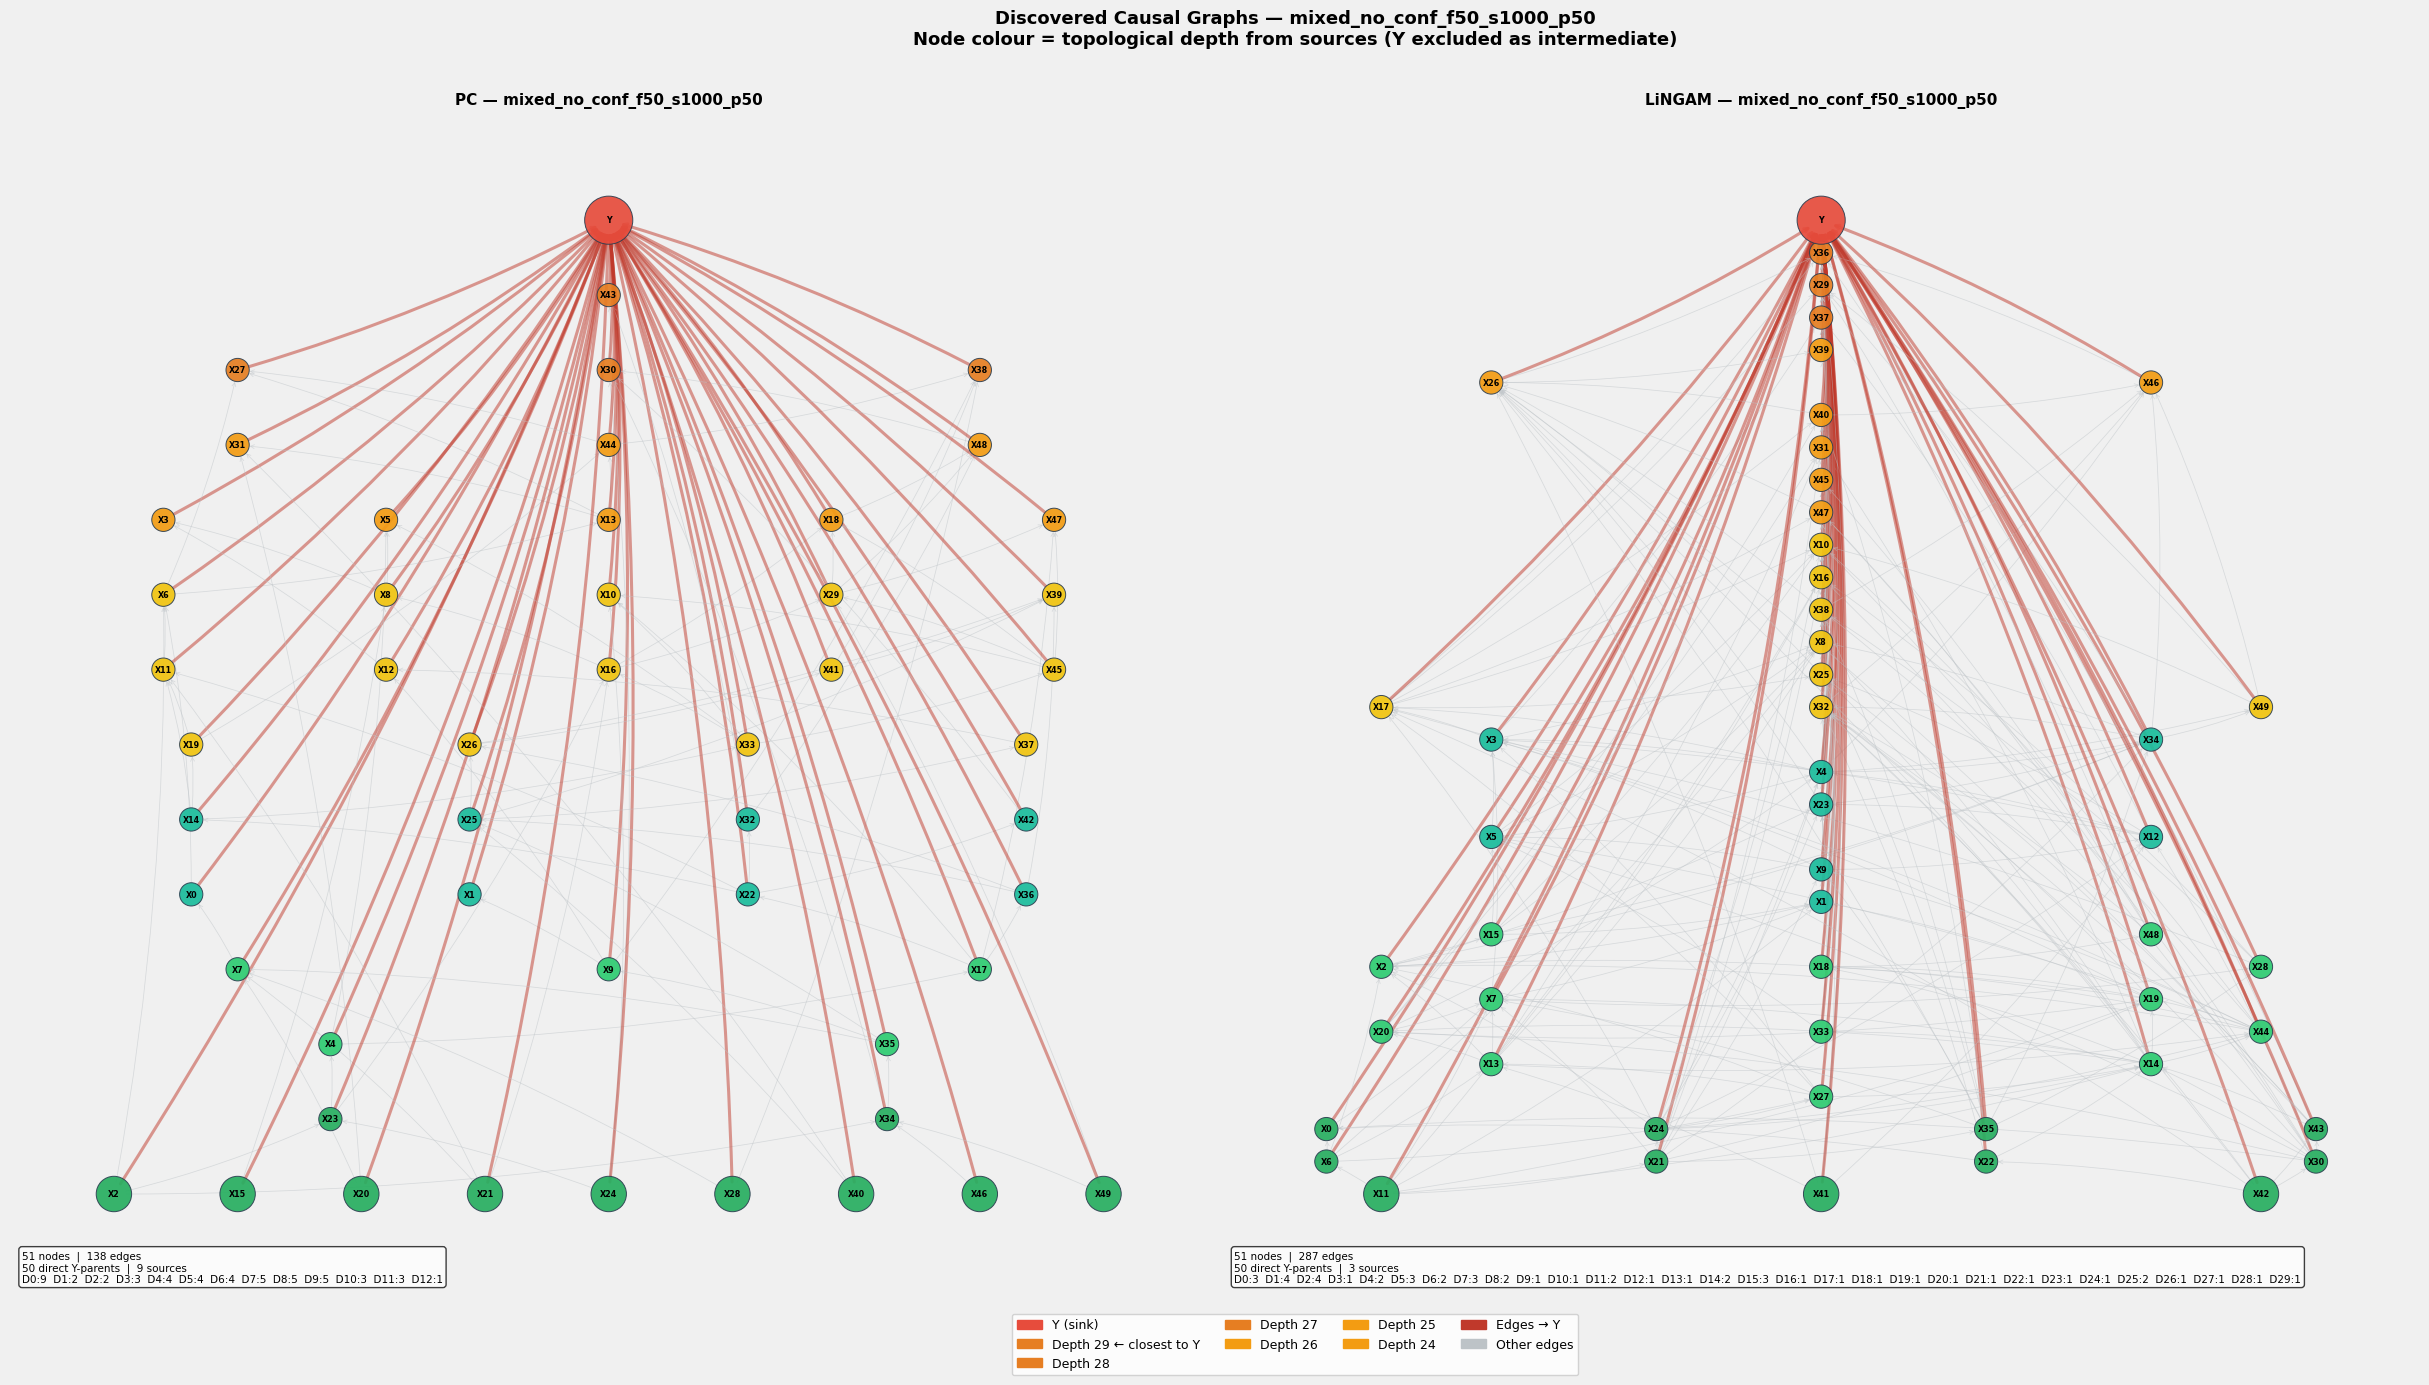

✅  Saved dag_comparison_mixed_no_conf_f50_s1000_p50.png

Metric                                   PC     LiNGAM
──────────────────────────────────────────────────────
  Total nodes                            51         51
  Total edges                           138        287
  Direct Y-parents                       50         50
  Source nodes (depth 0)                  9          3
  Max topo depth                         12         29
  Nodes at depth 0                        9          3
  Nodes at depth 1                        2          4
  Nodes at depth 2                        2          4
  Nodes at depth 3                        3          1
  Nodes at depth 4                        4          2
  Nodes at depth 5                        4          3
  Nodes at depth 6                        4          2
  Nodes at depth 7                        5          3
  Nodes at depth 8                        5          2
  Nodes at depth 9                        5          1
  Nodes 

In [12]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import collections

# ── Load both discovery results for the current DATASET ──────────────────────
def load_dag(causal_dir, dataset, method):
    path = causal_dir / f"{dataset}_{method}_results.json"
    with open(path) as f:
        r = json.load(f)
    return np.array(r["adjacency_matrix"]), r["feature_names"]

pc_adj,     pc_names     = load_dag(CAUSAL_DIR, DATASET, "pc")
lingam_adj, lingam_names = load_dag(CAUSAL_DIR, DATASET, "lingam")

# ── Helper: build graph + topological depth from sources ─────────────────────
# BFS from Y collapses all direct Y-parents to level 1, hiding structural depth.
# Topological depth = longest path from any source to each node,
# computed in the subgraph that excludes Y as a destination (O(V+E) Kahn).
def build_dag_graph(adj, names):
    n = len(names)
    y_idx = names.index("Y")

    G = nx.DiGraph()
    for i in range(n):
        G.add_node(i, label=names[i])
    for i in range(n):
        for j in range(n):
            if adj[i, j] != 0:
                G.add_edge(i, j)

    # Source nodes (no parents in the full graph)
    parents_full = {i: [j for j in range(n) if adj[j, i] != 0] for i in range(n)}
    sources = {i for i in range(n) if len(parents_full[i]) == 0 and i != y_idx}

    # Topological depth via Kahn's algorithm, excluding Y as intermediate
    non_y           = [i for i in range(n) if i != y_idx]
    children_no_y   = {u: [v for v in range(n) if adj[u, v] != 0 and v != y_idx]
                        for u in non_y}
    parents_no_y    = {v: [] for v in non_y}
    for u, ch in children_no_y.items():
        for v in ch:
            parents_no_y[v].append(u)

    in_deg    = {nd: len(parents_no_y[nd]) for nd in non_y}
    topo_depth = {nd: 0 for nd in non_y}
    queue      = [nd for nd in non_y if in_deg[nd] == 0]
    while queue:
        node = queue.pop(0)
        for child in children_no_y.get(node, []):
            topo_depth[child] = max(topo_depth[child], topo_depth[node] + 1)
            in_deg[child] -= 1
            if in_deg[child] == 0:
                queue.append(child)

    max_depth = max(topo_depth.values()) if topo_depth else 0
    topo_depth[y_idx] = max_depth + 1   # Y sits one step above the deepest node

    level_groups = {}
    for nd, d in topo_depth.items():
        level_groups.setdefault(d, []).append(nd)
    for d in level_groups:
        level_groups[d].sort()

    return G, topo_depth, level_groups, sources, y_idx, max_depth

# ── Layout: Y at top, sources at bottom ──────────────────────────────────────
# display_y = -(max_depth + 1 - depth) * Y_STEP
# → Y (depth = max_depth+1) → display_y = 0  (top)
# → sources (depth = 0)      → display_y = -(max_depth+1)*Y_STEP  (bottom)
def make_pos(level_groups, max_depth):
    Y_STEP  = 2.5
    H_SCALE = 1.4
    pos = {}
    for d, nodes in level_groups.items():
        n = len(nodes)
        h_gap = max(0.6, H_SCALE * 22 / max(n, 1))
        y_coord = -(max_depth + 1 - d) * Y_STEP
        for k, node in enumerate(nodes):
            pos[node] = ((k - (n - 1) / 2) * h_gap, y_coord)
    return pos

# ── Colour by proximity to Y: closest=orange, sources=green, Y=red ───────────
PROX_PALETTE = ["#e67e22", "#f39c12", "#f1c40f", "#1abc9c", "#2ecc71", "#27ae60"]

def _node_color(node_idx, topo_depth, max_depth, y_idx):
    if node_idx == y_idx:
        return "#e74c3c"
    prox = max_depth - topo_depth.get(node_idx, 0)
    if max_depth == 0:
        return PROX_PALETTE[0]
    idx = int(round(prox / max_depth * (len(PROX_PALETTE) - 1)))
    return PROX_PALETTE[min(idx, len(PROX_PALETTE) - 1)]

# ── Draw one DAG onto an axis ─────────────────────────────────────────────────
def draw_dag(ax, G, pos, topo_depth, sources, y_idx, max_depth, title):
    nc = [_node_color(nd, topo_depth, max_depth, y_idx) for nd in G.nodes()]
    ns = [1200 if nd == y_idx else (650 if nd in sources else 280) for nd in G.nodes()]
    ec = ["#c0392b" if v == y_idx else "#bdc3c7" for u, v in G.edges()]
    ew = [2.2 if v == y_idx else 0.55 for u, v in G.edges()]

    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=ec, width=ew, alpha=0.5,
                           arrows=True, arrowstyle="->", arrowsize=7,
                           connectionstyle="arc3,rad=0.05")
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=nc, node_size=ns,
                           alpha=0.92, linewidths=0.7, edgecolors="#2c3e50")
    nx.draw_networkx_labels(G, pos, {nd: G.nodes[nd]["label"] for nd in G.nodes()},
                            ax=ax, font_size=5.8, font_weight="bold")

    n_direct  = sum(1 for u, v in G.edges() if v == y_idx)
    depth_dist = collections.Counter(v for k, v in topo_depth.items() if k != y_idx)
    stats_str = (
        f"{G.number_of_nodes()} nodes  |  {G.number_of_edges()} edges\n"
        f"{n_direct} direct Y-parents  |  {len(sources)} sources\n"
        + "  ".join(f"D{d}:{depth_dist[d]}" for d in sorted(depth_dist))
    )
    ax.text(0.01, 0.01, stats_str, transform=ax.transAxes,
            fontsize=7.5, va="bottom", ha="left",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.75))
    ax.set_title(title, fontsize=11, fontweight="bold", pad=10)
    ax.axis("off")
    ax.set_facecolor("#f8f9fa")

# ── Build and draw ────────────────────────────────────────────────────────────
G_pc,     td_pc,     lvg_pc,     src_pc,     y_pc,     ml_pc     = build_dag_graph(pc_adj,     pc_names)
G_lingam, td_lingam, lvg_lingam, src_lingam, y_lingam, ml_lingam = build_dag_graph(lingam_adj, lingam_names)

pos_pc     = make_pos(lvg_pc,     ml_pc)
pos_lingam = make_pos(lvg_lingam, ml_lingam)

fig_dags, axes = plt.subplots(1, 2, figsize=(26, 14))
fig_dags.patch.set_facecolor("#f0f0f0")

draw_dag(axes[0], G_pc,     pos_pc,     td_pc,     src_pc,     y_pc,     ml_pc,
         f"PC — {DATASET}")
draw_dag(axes[1], G_lingam, pos_lingam, td_lingam, src_lingam, y_lingam, ml_lingam,
         f"LiNGAM — {DATASET}")

# Shared legend (proximity-based, not BFS-based)
max_lv_both = max(ml_pc, ml_lingam)
legend_entries = [mpatches.Patch(color="#e74c3c", label="Y (sink)")]
for prox in range(min(len(PROX_PALETTE), max_lv_both + 1)):
    idx = int(round(prox / max(max_lv_both, 1) * (len(PROX_PALETTE) - 1)))
    col = PROX_PALETTE[min(idx, len(PROX_PALETTE) - 1)]
    d   = max_lv_both - prox
    lbl = (f"Depth {d} — sources (no parents)" if prox == max_lv_both
           else f"Depth {d}" + (" ← closest to Y" if prox == 0 else ""))
    legend_entries.append(mpatches.Patch(color=col, label=lbl))
legend_entries += [mpatches.Patch(color="#c0392b", label="Edges → Y"),
                   mpatches.Patch(color="#bdc3c7", label="Other edges")]
fig_dags.legend(handles=legend_entries, loc="lower center", ncol=4, fontsize=9,
                framealpha=0.85, bbox_to_anchor=(0.5, 0.01))

fig_dags.suptitle(
    f"Discovered Causal Graphs — {DATASET}\n"
    f"Node colour = topological depth from sources (Y excluded as intermediate)",
    fontsize=13, fontweight="bold", y=0.99,
)
plt.tight_layout(rect=[0, 0.06, 1, 0.98])
plt.savefig(f"dag_comparison_{DATASET}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅  Saved dag_comparison_{DATASET}.png")

# ── Comparison table ──────────────────────────────────────────────────────────
print(f"\n{'Metric':<32} {'PC':>10} {'LiNGAM':>10}")
print("─" * 54)
print(f"  {'Total nodes':<30} {G_pc.number_of_nodes():>10} {G_lingam.number_of_nodes():>10}")
print(f"  {'Total edges':<30} {G_pc.number_of_edges():>10} {G_lingam.number_of_edges():>10}")
print(f"  {'Direct Y-parents':<30} {sum(1 for u,v in G_pc.edges() if v==y_pc):>10} {sum(1 for u,v in G_lingam.edges() if v==y_lingam):>10}")
print(f"  {'Source nodes (depth 0)':<30} {len(src_pc):>10} {len(src_lingam):>10}")
print(f"  {'Max topo depth':<30} {ml_pc:>10} {ml_lingam:>10}")
for d in range(max_lv_both + 1):
    pc_cnt = sum(1 for nd, dep in td_pc.items()     if dep == d and nd != y_pc)
    lg_cnt = sum(1 for nd, dep in td_lingam.items() if dep == d and nd != y_lingam)
    direct_note = " (closest to Y)" if d == max_lv_both else ""
    print(f"  {'Nodes at depth ' + str(d) + direct_note:<30} {pc_cnt:>10} {lg_cnt:>10}")


In [13]:
pc_adj[:,4].sum()

np.float64(1.0)